# SMA 50/200 with Transaction Costs, Across 8 ETFs

**Question:** does the golden-cross strategy hold up across asset classes once realistic trading costs are modeled?

**Universe:** broad-market (SPY, QQQ, IWM) and sectors (XLF financials, XLK tech, XLE energy, XLV health care, XLP staples).

**Cost levels:** 0, 5, 10, 25 bps one-way (a round trip is twice this).

**Output:** heatmap of Sharpe ratio for each (ticker, cost) combination, plus comparison vs buy-and-hold.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TRADING_DAYS = 252
START = '2016-01-01'
END = '2026-05-08'
TICKERS = ['SPY', 'QQQ', 'IWM', 'XLF', 'XLK', 'XLE', 'XLV', 'XLP']
COST_BPS_ONE_WAY = [0, 5, 10, 25]
FAST, SLOW = 50, 200

## 1. Download price data

In [2]:
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'] if 'Close' in raw.columns.get_level_values(0) else raw
prices = prices.dropna()
print(f'Rows: {len(prices)}  Range: {prices.index.min().date()} to {prices.index.max().date()}')
prices.head()

Rows: 2601  Range: 2016-01-04 to 2026-05-07


Ticker,IWM,QQQ,SPY,XLE,XLF,XLK,XLP,XLV
Date,,,,,,,,
2016-01-04,96.464211,101.717270,169.908173,19.955769,15.678115,18.860451,37.954151,59.637379
2016-01-05,96.674683,101.540817,170.195526,20.031885,15.738498,18.811369,38.197796,59.924065
2016-01-06,95.201530,100.565422,168.048615,19.260796,15.496990,18.579353,38.068356,59.435040
2016-01-07,92.658630,97.416389,164.016891,18.790857,15.060924,18.030539,37.611526,58.229301
2016-01-08,91.062714,96.617477,162.216553,18.549265,14.826121,17.887758,37.322205,57.352406


## 2. Backtest helpers

In [3]:
def backtest_sma(close: pd.Series, fast: int, slow: int, cost_bps: float):
    df = pd.DataFrame({'close': close})
    df['sma_fast'] = df['close'].rolling(fast).mean()
    df['sma_slow'] = df['close'].rolling(slow).mean()
    df['position'] = (df['sma_fast'] > df['sma_slow']).astype(int).shift(1).fillna(0)
    df['trade'] = df['position'].diff().abs().fillna(0)  # 1 on entry or exit days
    df['ret'] = df['close'].pct_change().fillna(0)
    df['strat_ret'] = df['ret'] * df['position'] - (cost_bps / 10000.0) * df['trade']
    df['equity'] = (1 + df['strat_ret']).cumprod()
    return df

def perf_metrics(returns: pd.Series, equity: pd.Series, n_trades: int = None) -> dict:
    years = len(returns) / TRADING_DAYS
    final = equity.iloc[-1]
    cagr = final ** (1 / years) - 1 if final > 0 else -1
    sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS) if returns.std() > 0 else 0
    dd = (equity / equity.cummax() - 1).min()
    out = {'total_return': final - 1, 'cagr': cagr, 'sharpe': sharpe, 'max_dd': dd}
    if n_trades is not None:
        out['n_trades'] = n_trades
    return out

## 3. Run grid: ticker x cost level

In [4]:
rows = []
for ticker in TICKERS:
    series = prices[ticker]
    bh_ret = series.pct_change().fillna(0)
    bh_eq = (1 + bh_ret).cumprod()
    bh = perf_metrics(bh_ret, bh_eq)
    rows.append({'ticker': ticker, 'cost_bps': 'buy_hold', **bh})
    for cost in COST_BPS_ONE_WAY:
        bt = backtest_sma(series, FAST, SLOW, cost)
        m = perf_metrics(bt['strat_ret'], bt['equity'], int(bt['trade'].sum()))
        rows.append({'ticker': ticker, 'cost_bps': cost, **m})

results = pd.DataFrame(rows)
results

,ticker,cost_bps,total_return,cagr,sharpe,max_dd,n_trades
0,SPY,buy_hold,3.305738,0.151941,0.880848,-0.337173,NaN
1,SPY,0,1.740785,0.102615,0.735606,-0.337173,9.0
2,SPY,5,1.728473,0.102134,0.732641,-0.337173,9.0
3,SPY,10,1.716210,0.101653,0.729668,-0.337173,9.0
4,SPY,25,1.679714,0.100210,0.720709,-0.337173,9.0
5,QQQ,buy_hold,5.832075,0.204637,0.949640,-0.351187,NaN
6,QQQ,0,4.541708,0.180453,0.979889,-0.285594,9.0
7,QQQ,5,4.516971,0.179941,0.977624,-0.285594,9.0
8,QQQ,10,4.492332,0.179429,0.975353,-0.285594,9.0
9,QQQ,25,4.419001,0.177894,0.968501,-0.285594,9.0


## 4. Heatmap: Sharpe by ticker x cost

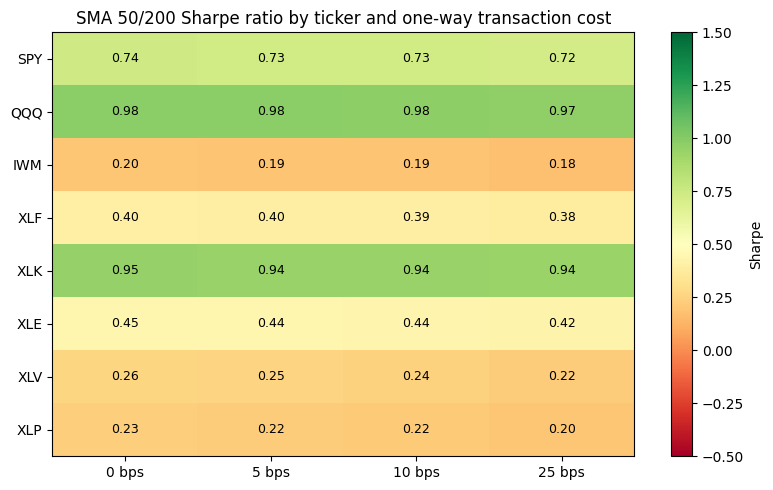

In [5]:
strat_only = results[results['cost_bps'] != 'buy_hold'].copy()
strat_only['cost_bps'] = strat_only['cost_bps'].astype(int)
sharpe_pivot = strat_only.pivot(index='ticker', columns='cost_bps', values='sharpe').loc[TICKERS]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(sharpe_pivot.values, cmap='RdYlGn', vmin=-0.5, vmax=1.5, aspect='auto')
ax.set_xticks(range(len(sharpe_pivot.columns)))
ax.set_xticklabels([f'{c} bps' for c in sharpe_pivot.columns])
ax.set_yticks(range(len(sharpe_pivot.index)))
ax.set_yticklabels(sharpe_pivot.index)
for i in range(sharpe_pivot.shape[0]):
    for j in range(sharpe_pivot.shape[1]):
        ax.text(j, i, f'{sharpe_pivot.values[i, j]:.2f}', ha='center', va='center', color='black', fontsize=9)
ax.set_title('SMA 50/200 Sharpe ratio by ticker and one-way transaction cost')
plt.colorbar(im, ax=ax, label='Sharpe')
plt.tight_layout()
plt.show()

## 5. Strategy vs buy-hold (Sharpe delta)

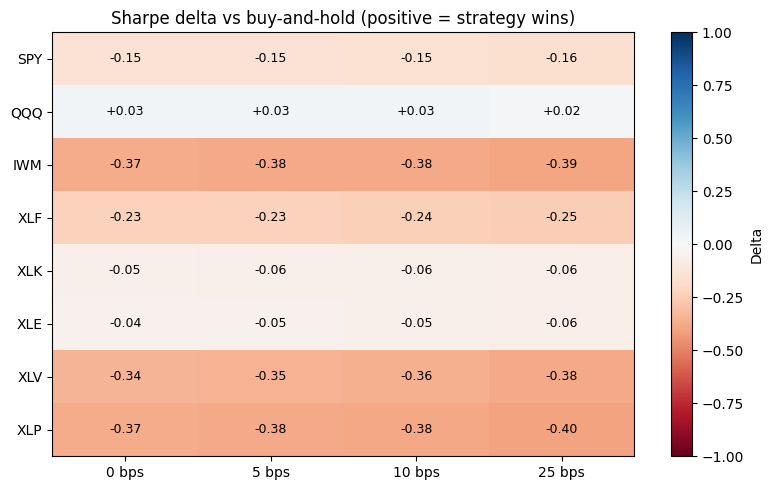

In [6]:
bh_sharpe = results[results['cost_bps'] == 'buy_hold'].set_index('ticker')['sharpe']
delta = sharpe_pivot.subtract(bh_sharpe, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(delta.values, cmap='RdBu', vmin=-1.0, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(delta.columns)))
ax.set_xticklabels([f'{c} bps' for c in delta.columns])
ax.set_yticks(range(len(delta.index)))
ax.set_yticklabels(delta.index)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        ax.text(j, i, f'{delta.values[i, j]:+.2f}', ha='center', va='center', color='black', fontsize=9)
ax.set_title('Sharpe delta vs buy-and-hold (positive = strategy wins)')
plt.colorbar(im, ax=ax, label='Delta')
plt.tight_layout()
plt.show()

## 6. Drawdown comparison at 5 bps cost

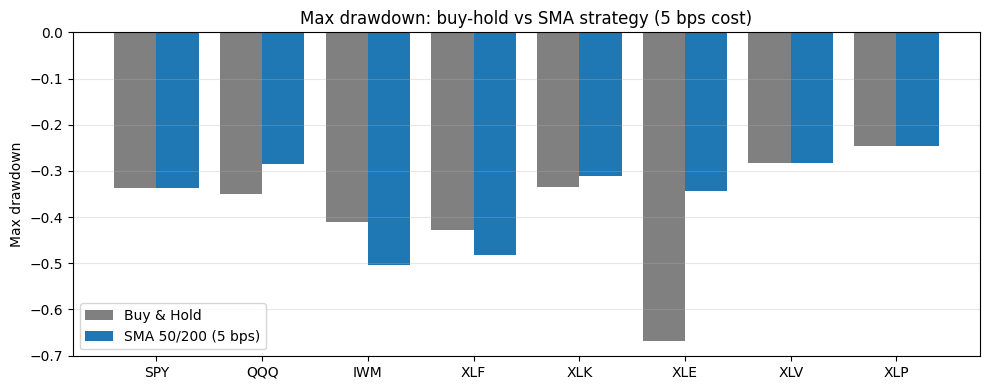

,buy_hold_dd,strat_dd_5bps,dd_improvement
ticker,,,
SPY,-0.337173,-0.337173,2.220446e-16
QQQ,-0.351187,-0.285594,6.559351e-02
IWM,-0.411333,-0.504301,-9.296818e-02
XLF,-0.428625,-0.482469,-5.384393e-02
XLK,-0.335591,-0.311532,2.405845e-02
XLE,-0.668130,-0.342715,3.254154e-01
XLV,-0.284043,-0.284043,-2.220446e-16
XLP,-0.245122,-0.245122,-2.220446e-16


In [7]:
dd_compare = []
for ticker in TICKERS:
    series = prices[ticker]
    bh_eq = (1 + series.pct_change().fillna(0)).cumprod()
    bh_dd = (bh_eq / bh_eq.cummax() - 1).min()
    bt = backtest_sma(series, FAST, SLOW, 5)
    st_dd = (bt['equity'] / bt['equity'].cummax() - 1).min()
    dd_compare.append({'ticker': ticker, 'buy_hold_dd': bh_dd, 'strat_dd_5bps': st_dd, 'dd_improvement': st_dd - bh_dd})
dd_df = pd.DataFrame(dd_compare).set_index('ticker')

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(dd_df))
ax.bar(x - 0.2, dd_df['buy_hold_dd'], width=0.4, label='Buy & Hold', color='gray')
ax.bar(x + 0.2, dd_df['strat_dd_5bps'], width=0.4, label='SMA 50/200 (5 bps)', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(dd_df.index)
ax.set_ylabel('Max drawdown')
ax.set_title('Max drawdown: buy-hold vs SMA strategy (5 bps cost)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
dd_df

## Notes

- **Cost model is one-way bps applied on each trade event** (entry or exit). A 5 bps one-way cost = 10 bps round-trip.
- **Window:** 2016-01-01 to 2026-05-08 — 10 years, includes COVID crash, 2022 bear, 2023-2024 rally.
- **No slippage, no bid-ask, no borrow costs**, no overnight financing. Real institutions face all of these.
- **No regime mixing:** strategy is run identically on each ticker. In practice you would calibrate windows per asset.
- **Survivorship bias:** these tickers all exist today. Sectors that died (think individual stocks) are not in this universe.

## Honest read

Trend-following on broad indices typically loses CAGR but trims tail drawdowns. The Sharpe-delta heatmap shows where (if anywhere) the trim is worth the give-up. Sectors with cleaner regime changes (XLE energy, XLF financials around 2008/2020) tend to favor the strategy more than smooth-trending tech (XLK, QQQ).

## Next experiments

1. Volatility-targeted position sizing instead of binary 0/1.
2. Longer history with extended futures data.
3. Add a defensive overlay: hold T-bill yield (^IRX) when out of the market.
4. Walk-forward optimization of SMA windows per asset.